# Compare SDAN with sciRED and Spectra using loading vectors

This notebook compares SDAN programs $G_k$ against sciRED and Spectra loading vectors directly.

For each SDAN program $k$ and each comparison factor $j$:
- genes in $G_k$ are treated as positives,
- the remaining assayed genes are treated as negatives,
- all genes are ranked by loading magnitude,
- AUROC and average precision are computed.

Interpretation:
- high AUROC or AP means the comparison factor `j` gives high weight to the genes that define SDAN program `k`,
- this is a natural dense-vs-sparse comparison because SDAN contributes sparse program memberships while sciRED and Spectra contribute dense loading vectors.

This notebook is set up to analyze both `cd4_BL` and `cd8_BL` in the `Su_2020` dataset.


In [61]:
import os
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score

sns.set_theme(context="notebook", style="white")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)


In [62]:
def find_repo_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "SDAN_Comparison").exists() and ((path / "Su_2020").exists() or (path / "SEA_AD").exists()):
            return path
    raise FileNotFoundError("Could not locate repo root containing SDAN_Comparison/ and a supported dataset directory.")


DATASET_CONFIG = {
    "Su_2020": {
        "study_dir": "Su_2020",
        "cell_types": ["cd4_BL", "cd8_BL"],
        "spectra_gene_list": "gene_list_cd4_cd8_union.txt",
        "spectra_loading": "train_s_cd4_cd8_BL_Spectra_union.npy",
    },
    "SEA_AD": {
        "study_dir": "SEA_AD",
        "cell_types": ["Astro", "Micro-PVM"],
        "spectra_gene_list": "gene_list_Astro_Micro-PVM_union_filtered.txt",
        "spectra_loading": "train_s_Astro_Micro-PVM_union.npy",
    },
}


DATASET = "Su_2020"
if DATASET not in DATASET_CONFIG:
    raise ValueError(f"Unsupported dataset: {DATASET}. Choose from {sorted(DATASET_CONFIG)}")

REPO_ROOT = find_repo_root()
DATASET_INFO = DATASET_CONFIG[DATASET]
CELL_TYPES = DATASET_INFO["cell_types"]
DEFAULT_WEIGHT = "2.0"
CONNECTIVITY_WEIGHT_DEFAULT = DEFAULT_WEIGHT
CONNECTIVITY_THRESHOLD_DEFAULT = 0.8

SDAN_OUTPUT = REPO_ROOT / DATASET_INFO["study_dir"] / "output"
SCIRED_OUTPUT = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "sciRED"
SPECTRA_OUTPUT = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "Spectra"
RESULTS_DIR = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "SDAN_vs_sciRED_loading"
SPECTRA_RESULTS_DIR = REPO_ROOT / "SDAN_Comparison" / DATASET_INFO["study_dir"] / "output_comparison" / "SDAN_vs_Spectra_loading"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SPECTRA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATASET: {DATASET}")
print(f"RESULTS_DIR: {RESULTS_DIR}")


REPO_ROOT: /Users/zxlin/Documents/GitHub/SDAN
DATASET: Su_2020
RESULTS_DIR: /Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Su_2020/output_comparison/SDAN_vs_sciRED_loading


In [63]:
def read_program_gene_sets(path: Path) -> dict[str, set[str]]:
    programs = {}
    for idx, line in enumerate(path.read_text().strip().splitlines()):
        genes = [gene.strip() for gene in line.split(",") if gene.strip()]
        programs[f"SDAN_{idx}"] = set(genes)
    return programs


def load_sdan_scired_inputs(cell_type: str, sdan_weight: str = "2.0"):
    gene_list_path = SDAN_OUTPUT / f"gene_list_{cell_type}_{sdan_weight}.txt"
    program_path = SDAN_OUTPUT / f"name_s_{cell_type}_{sdan_weight}.txt"
    scired_path = SCIRED_OUTPUT / f"varimax_loading_{cell_type}_sciRED.csv"

    gene_universe = pd.read_csv(gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    program_gene_sets = read_program_gene_sets(program_path)

    scired = pd.read_csv(scired_path).rename(columns={"Unnamed: 0": "gene"})
    scired["gene"] = scired["gene"].astype(str)
    factor_cols = [col for col in scired.columns if col != "gene"]

    return gene_universe, program_gene_sets, scired, factor_cols


def compute_program_factor_metrics(cell_type: str, sdan_weight: str = "2.0"):
    gene_universe, program_gene_sets, scired, factor_cols = load_sdan_scired_inputs(cell_type, sdan_weight)
    scired = scired.drop_duplicates(subset="gene").set_index("gene")

    common_genes = [gene for gene in gene_universe if gene in scired.index]
    score_matrix = scired.loc[common_genes, factor_cols].abs()

    rows = []
    for program_name, genes_in_program in program_gene_sets.items():
        y_true = np.array([gene in genes_in_program for gene in common_genes], dtype=int)
        positive_genes = int(y_true.sum())
        negative_genes = int((1 - y_true).sum())

        if positive_genes == 0 or negative_genes == 0:
            continue

        for factor_name in factor_cols:
            y_score = score_matrix[factor_name].to_numpy()
            rows.append(
                {
                    "cell_type": cell_type,
                    "sdan_weight": sdan_weight,
                    "program": program_name,
                    "factor": factor_name,
                    "n_genes_overlap": len(common_genes),
                    "n_program_genes_total": len(genes_in_program),
                    "n_program_genes_overlap": positive_genes,
                    "auroc": roc_auc_score(y_true, y_score),
                    "average_precision": average_precision_score(y_true, y_score),
                }
            )

    metrics = pd.DataFrame(rows)
    auroc_mat = metrics.pivot(index="program", columns="factor", values="auroc")
    ap_mat = metrics.pivot(index="program", columns="factor", values="average_precision")

    program_summary = (
        metrics[["program", "n_genes_overlap", "n_program_genes_total", "n_program_genes_overlap"]]
        .drop_duplicates()
        .sort_values("program")
        .reset_index(drop=True)
    )

    return {
        "common_genes": common_genes,
        "metrics": metrics,
        "auroc": auroc_mat,
        "average_precision": ap_mat,
        "program_summary": program_summary,
    }


def summarize_best_matches(metrics: pd.DataFrame, metric: str) -> pd.DataFrame:
    best = metrics.loc[metrics.groupby("program")[metric].idxmax()].copy()
    return best.sort_values(metric, ascending=False).reset_index(drop=True)


def plot_metric_heatmap(metric_matrix: pd.DataFrame, title: str, cmap: str = "viridis"):
    plt.figure(figsize=(14, 10))
    sns.heatmap(metric_matrix, cmap=cmap, vmin=0.0, vmax=1.0)
    plt.title(title)
    plt.xlabel("sciRED factor")
    plt.ylabel("SDAN program")
    plt.tight_layout()
    plt.show()


def load_sdan_program_matrix(cell_type: str, sdan_weight: str = "2.0"):
    train_s_path = SDAN_OUTPUT / f"train_s_{cell_type}_{sdan_weight}.npy"
    gene_list_path = SDAN_OUTPUT / f"gene_list_{cell_type}_{sdan_weight}.txt"
    train_s = np.load(train_s_path)
    gene_list = pd.read_csv(gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    return train_s, gene_list


def construct_gene_graph_array(gene_list):
    mapping = pd.Series(range(len(gene_list)), index=pd.Index(gene_list))
    edge_df = pd.read_csv(
        REPO_ROOT / "Annotation" / "BIOGRID-ORGANISM-Homo_sapiens-4.4.204.tab3.txt.gz",
        compression="gzip",
        sep="\t",
        low_memory=False,
        usecols=["Official Symbol Interactor A", "Official Symbol Interactor B"],
    )
    edge_df = edge_df[
        edge_df["Official Symbol Interactor A"].isin(gene_list)
        & edge_df["Official Symbol Interactor B"].isin(gene_list)
    ].drop_duplicates()

    edge_array = np.vstack([
        edge_df.iloc[:, 0].map(mapping).to_numpy(dtype=np.int64),
        edge_df.iloc[:, 1].map(mapping).to_numpy(dtype=np.int64),
    ]).T

    reverse_edges = edge_array[:, ::-1]
    edge_array = np.vstack([edge_array, reverse_edges])
    edge_array = edge_array[edge_array[:, 0] != edge_array[:, 1]]
    edge_array = np.unique(edge_array, axis=0)
    return edge_array


def compute_sdan_connectivity_quantiles(
    cell_type: str,
    sdan_weight: str = "2.0",
    threshold: float = 0.8,
    n_random: int = 50,
    seed: int = 888,
):
    train_s, gene_list = load_sdan_program_matrix(cell_type, sdan_weight)
    edge_array = construct_gene_graph_array(gene_list)
    rng = np.random.default_rng(seed)

    rows = []
    for idx in range(train_s.shape[1]):
        gene_index = np.where(train_s[:, idx] > threshold)[0]
        if len(gene_index) == 0:
            continue

        gene_index_set = set(gene_index.tolist())
        edge_count = sum(
            1 for a, b in edge_array
            if int(a) in gene_index_set and int(b) in gene_index_set
        )
        avg_degree = 2 * edge_count / len(gene_index)

        random_degrees = np.zeros(n_random, dtype=float)
        for j in range(n_random):
            random_index = rng.choice(len(gene_list), size=len(gene_index), replace=False)
            random_index_set = set(random_index.tolist())
            random_edge_count = sum(
                1 for a, b in edge_array
                if int(a) in random_index_set and int(b) in random_index_set
            )
            random_degrees[j] = 2 * random_edge_count / len(gene_index)

        rows.append(
            {
                "cell_type": cell_type,
                "sdan_weight": sdan_weight,
                "program": f"SDAN_{idx}",
                "n_active_genes": int(len(gene_index)),
                "n_internal_edges": int(edge_count),
                "avg_degree": float(avg_degree),
                "connectivity_quantile": float((random_degrees < avg_degree).mean()),
            }
        )

    return pd.DataFrame(rows).sort_values("program").reset_index(drop=True)


def read_h5ad_obs_column(obs_group, column: str) -> np.ndarray:
    obj = obs_group[column]
    if isinstance(obj, h5py.Group):
        categories = [
            c.decode("utf-8") if isinstance(c, bytes) else str(c)
            for c in obj["categories"][:]
        ]
        codes = obj["codes"][:].astype(int)
        return np.array([categories[code] if code >= 0 else None for code in codes], dtype=object)

    values = obj[:]
    return np.array(
        [
            value.decode("utf-8") if isinstance(value, bytes) else str(value)
            for value in values
        ],
        dtype=object,
    )


def infer_individual_ids(obs_group, cell_type: str) -> np.ndarray:
    for candidate in ["individual", "donor_id", "Donor ID", "participant", "subject_id", "sample_id"]:
        if candidate in obs_group:
            return read_h5ad_obs_column(obs_group, candidate)

    if DATASET == "Su_2020":
        barcode_col = "barcode" if "barcode" in obs_group else ("_index" if "_index" in obs_group else None)
        if barcode_col is not None:
            barcodes = read_h5ad_obs_column(obs_group, barcode_col)
            meta_cell_path = REPO_ROOT / DATASET_INFO["study_dir"] / f"cell_info_{cell_type}.csv"
            meta_cell = pd.read_csv(meta_cell_path, usecols=["V1", "individual"])
            barcode_to_individual = (
                meta_cell.drop_duplicates(subset="V1")
                .assign(V1=lambda x: x["V1"].astype(str), individual=lambda x: x["individual"].astype(str))
                .set_index("V1")["individual"]
            )
            mapped = pd.Series(barcodes.astype(str)).map(barcode_to_individual)
            if mapped.isna().any():
                n_missing = int(mapped.isna().sum())
                raise KeyError(
                    f"Could not map {n_missing} cells to individuals from {meta_cell_path}. "
                    f"Checked barcode source '{barcode_col}'."
                )
            return mapped.to_numpy(dtype=object)

    raise KeyError(
        "Missing individual-level identifier in test_reduced obs. "
        "Expected one of: individual, donor_id, Donor ID, participant, subject_id, sample_id; "
        "or Su_2020 barcode/_index mappable via cell_info_<cell_type>.csv."
    )


def load_test_reduced_labels_and_scores(cell_type: str, sdan_weight: str = "2.0"):
    test_reduced_path = SDAN_OUTPUT / f"test_reduced_{cell_type}_{sdan_weight}.h5ad"
    with h5py.File(test_reduced_path, "r") as f:
        x = f["X"][:]
        obs_group = f["obs"]
        labels = read_h5ad_obs_column(obs_group, "cell_type")
        individuals = infer_individual_ids(obs_group, cell_type)

    return labels, individuals, x


def compute_sdan_test_separation_scores(cell_type: str, sdan_weight: str = "2.0") -> pd.DataFrame:
    labels, individuals, x = load_test_reduced_labels_and_scores(cell_type, sdan_weight)
    mask = np.isin(labels, ["mild", "severe"])
    labels = labels[mask]
    individuals = individuals[mask]
    x = x[mask]
    y_true = (labels == "severe").astype(int)

    label_df = pd.DataFrame({"individual": individuals, "label": labels}).drop_duplicates()
    label_conflicts = label_df.groupby("individual")["label"].nunique()
    if (label_conflicts > 1).any():
        bad_individuals = label_conflicts[label_conflicts > 1].index.tolist()
        raise ValueError(f"Found inconsistent labels for individuals: {bad_individuals}")

    label_by_individual = (
        label_df.drop_duplicates(subset="individual")
        .set_index("individual")["label"]
        .sort_index()
    )
    individual_scores = (
        pd.DataFrame(x, columns=[f"SDAN_{idx}" for idx in range(x.shape[1])])
        .assign(individual=individuals)
        .groupby("individual", sort=True)
        .mean()
    )
    individual_labels = (label_by_individual.loc[individual_scores.index] == "severe").astype(int).to_numpy()

    rows = []
    for idx in range(x.shape[1]):
        program = f"SDAN_{idx}"
        rows.append(
            {
                "cell_type": cell_type,
                "sdan_weight": sdan_weight,
                "program": program,
                "test_group_auroc": float(roc_auc_score(y_true, x[:, idx])),
                "individual_level_auroc": float(roc_auc_score(individual_labels, individual_scores[program].to_numpy())),
            }
        )

    return pd.DataFrame(rows).sort_values("program").reset_index(drop=True)


def plot_program_score_vs_connectivity(
    metrics: pd.DataFrame,
    connectivity: pd.DataFrame,
    score_col: str = "average_precision",
    title: str = "",
):
    best = summarize_best_matches(metrics, score_col)
    plot_df = best.merge(connectivity, on=["cell_type", "sdan_weight", "program"], how="inner")

    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=plot_df, x=score_col, y="connectivity_quantile", s=70)
    plt.xlabel(score_col.replace("_", " ").title())
    plt.ylabel("Connectivity quantile")
    plt.title(title or f"{score_col} vs SDAN connectivity quantile")
    plt.ylim(-0.02, 1.02)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return plot_df


def plot_saved_best_match_score(
    best_df: pd.DataFrame,
    cell_type: str,
    score_col: str = "average_precision",
    title: str = "",
    hue_col: Optional[str] = None,
    palette: str = "viridis",
):
    plot_df = best_df[best_df["cell_type"] == cell_type].copy()
    fig, ax = plt.subplots(figsize=(7, 5))
    if hue_col is not None and hue_col in plot_df.columns:
        hue_values = pd.to_numeric(plot_df[hue_col], errors="coerce")
        valid = hue_values.notna()
        if valid.any():
            scatter = ax.scatter(
                plot_df.loc[valid, score_col],
                plot_df.loc[valid, "connectivity_quantile"],
                c=hue_values.loc[valid],
                cmap=palette,
                s=70,
            )
            cbar = fig.colorbar(scatter, ax=ax)
            cbar.set_label(hue_col.replace("_", " ").title())
            if (~valid).any():
                ax.scatter(
                    plot_df.loc[~valid, score_col],
                    plot_df.loc[~valid, "connectivity_quantile"],
                    color="lightgray",
                    s=70,
                )
        else:
            ax.scatter(plot_df[score_col], plot_df["connectivity_quantile"], s=70)
    else:
        ax.scatter(plot_df[score_col], plot_df["connectivity_quantile"], s=70)
    ax.set_xlabel(score_col.replace("_", " ").title())
    ax.set_ylabel("Connectivity quantile")
    ax.set_title(title or f"{cell_type}: {score_col} vs SDAN connectivity quantile")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    return plot_df


In [64]:
SDAN_WEIGHT = DEFAULT_WEIGHT

for CELL_TYPE in CELL_TYPES:
    result = compute_program_factor_metrics(CELL_TYPE, SDAN_WEIGHT)

    print(f"Cell type: {CELL_TYPE}")
    print(f"SDAN weight: {SDAN_WEIGHT}")
    print(f"Genes in SDAN universe: {result['program_summary']['n_genes_overlap'].iloc[0]} overlapping with sciRED loadings")
    display(result["program_summary"].head())

    best_auroc = summarize_best_matches(result["metrics"], "auroc")
    best_ap = summarize_best_matches(result["metrics"], "average_precision")

    display(best_auroc.head(10))
    display(best_ap.head(10))

    result["metrics"].to_csv(RESULTS_DIR / f"{CELL_TYPE}_vs_sciRED_program_factor_metrics.csv", index=False)

print("Saved CSV outputs to:")
print(RESULTS_DIR)


Cell type: cd4_BL
SDAN weight: 2.0
Genes in SDAN universe: 1974 overlapping with sciRED loadings


,program,n_genes_overlap,n_program_genes_total,n_program_genes_overlap
0,SDAN_0,1974,21,21
1,SDAN_1,1974,20,20
2,SDAN_10,1974,16,16
3,SDAN_11,1974,22,20
4,SDAN_12,1974,20,20


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd4_BL,2.0,SDAN_38,sciRED_4,1974,20,18,0.858953,0.227213
1,cd4_BL,2.0,SDAN_37,sciRED_14,1974,21,21,0.850974,0.095484
2,cd4_BL,2.0,SDAN_10,sciRED_7,1974,16,16,0.808159,0.399969
3,cd4_BL,2.0,SDAN_34,sciRED_5,1974,20,20,0.772876,0.143019
4,cd4_BL,2.0,SDAN_16,sciRED_14,1974,21,20,0.753608,0.109608
5,cd4_BL,2.0,SDAN_23,sciRED_0,1974,20,20,0.746750,0.023895
6,cd4_BL,2.0,SDAN_6,sciRED_4,1974,20,20,0.720983,0.072902
7,cd4_BL,2.0,SDAN_3,sciRED_3,1974,22,22,0.711694,0.063253
8,cd4_BL,2.0,SDAN_12,sciRED_15,1974,20,20,0.710619,0.042758
9,cd4_BL,2.0,SDAN_27,sciRED_24,1974,21,20,0.695855,0.041177


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd4_BL,2.0,SDAN_10,sciRED_7,1974,16,16,0.808159,0.399969
1,cd4_BL,2.0,SDAN_38,sciRED_4,1974,20,18,0.858953,0.227213
2,cd4_BL,2.0,SDAN_34,sciRED_5,1974,20,20,0.772876,0.143019
3,cd4_BL,2.0,SDAN_31,sciRED_25,1974,21,21,0.648794,0.122905
4,cd4_BL,2.0,SDAN_3,sciRED_13,1974,22,22,0.699073,0.121586
5,cd4_BL,2.0,SDAN_12,sciRED_11,1974,20,20,0.562871,0.111529
6,cd4_BL,2.0,SDAN_16,sciRED_14,1974,21,20,0.753608,0.109608
7,cd4_BL,2.0,SDAN_13,sciRED_12,1974,20,20,0.521469,0.095510
8,cd4_BL,2.0,SDAN_37,sciRED_14,1974,21,21,0.850974,0.095484
9,cd4_BL,2.0,SDAN_24,sciRED_11,1974,19,18,0.555698,0.081873


Cell type: cd8_BL
SDAN weight: 2.0
Genes in SDAN universe: 1616 overlapping with sciRED loadings


,program,n_genes_overlap,n_program_genes_total,n_program_genes_overlap
0,SDAN_0,1616,19,18
1,SDAN_1,1616,18,18
2,SDAN_10,1616,18,18
3,SDAN_11,1616,18,18
4,SDAN_12,1616,18,18


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd8_BL,2.0,SDAN_35,sciRED_2,1616,18,18,0.958385,0.218752
1,cd8_BL,2.0,SDAN_8,sciRED_20,1616,19,19,0.804040,0.066775
2,cd8_BL,2.0,SDAN_12,sciRED_2,1616,18,18,0.789946,0.032785
3,cd8_BL,2.0,SDAN_19,sciRED_36,1616,19,19,0.767854,0.047491
4,cd8_BL,2.0,SDAN_4,sciRED_4,1616,18,17,0.751242,0.028085
5,cd8_BL,2.0,SDAN_30,sciRED_23,1616,18,18,0.750834,0.191977
6,cd8_BL,2.0,SDAN_5,sciRED_19,1616,17,17,0.732222,0.031865
7,cd8_BL,2.0,SDAN_24,sciRED_25,1616,17,17,0.719898,0.145718
8,cd8_BL,2.0,SDAN_37,sciRED_9,1616,17,17,0.715925,0.062106
9,cd8_BL,2.0,SDAN_32,sciRED_7,1616,16,16,0.709570,0.255984


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd8_BL,2.0,SDAN_39,sciRED_19,1616,17,16,0.679688,0.335292
1,cd8_BL,2.0,SDAN_32,sciRED_7,1616,16,16,0.709570,0.255984
2,cd8_BL,2.0,SDAN_35,sciRED_2,1616,18,18,0.958385,0.218752
3,cd8_BL,2.0,SDAN_30,sciRED_23,1616,18,18,0.750834,0.191977
4,cd8_BL,2.0,SDAN_24,sciRED_25,1616,17,17,0.719898,0.145718
5,cd8_BL,2.0,SDAN_4,sciRED_5,1616,18,17,0.644042,0.125699
6,cd8_BL,2.0,SDAN_29,sciRED_18,1616,19,19,0.542333,0.121167
7,cd8_BL,2.0,SDAN_26,sciRED_17,1616,18,18,0.689438,0.118529
8,cd8_BL,2.0,SDAN_19,sciRED_38,1616,19,19,0.691889,0.095784
9,cd8_BL,2.0,SDAN_3,sciRED_24,1616,18,18,0.688534,0.091028


Saved CSV outputs to:
/Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Su_2020/output_comparison/SDAN_vs_sciRED_loading


In [65]:
# Optional: summarize the best sciRED matches for both Su_2020 cell types.

BATCH_WEIGHT = DEFAULT_WEIGHT
combined_best_ap = []
combined_best_auroc = []

for cell_type in CELL_TYPES:
    out = compute_program_factor_metrics(cell_type, BATCH_WEIGHT)
    connectivity = compute_sdan_connectivity_quantiles(
        cell_type,
        BATCH_WEIGHT,
        threshold=CONNECTIVITY_THRESHOLD_DEFAULT,
    )
    test_separation = compute_sdan_test_separation_scores(cell_type, BATCH_WEIGHT)
    best_ap = summarize_best_matches(out["metrics"], "average_precision")
    best_ap = best_ap.merge(connectivity, on=["cell_type", "sdan_weight", "program"], how="left")
    best_ap = best_ap.merge(test_separation, on=["cell_type", "sdan_weight", "program"], how="left")
    combined_best_ap.append(best_ap)
    best_auroc = summarize_best_matches(out["metrics"], "auroc")
    best_auroc = best_auroc.merge(connectivity, on=["cell_type", "sdan_weight", "program"], how="left")
    best_auroc = best_auroc.merge(test_separation, on=["cell_type", "sdan_weight", "program"], how="left")
    combined_best_auroc.append(best_auroc)

combined_best_ap = pd.concat(combined_best_ap, ignore_index=True)
combined_best_ap = combined_best_ap.sort_values(["cell_type", "average_precision"], ascending=[True, False])
display(combined_best_ap.groupby("cell_type").head(10))
combined_best_auroc = pd.concat(combined_best_auroc, ignore_index=True)
combined_best_auroc = combined_best_auroc.sort_values(["cell_type", "auroc"], ascending=[True, False])
display(combined_best_auroc.groupby("cell_type").head(10))

combined_best_ap.to_csv(RESULTS_DIR / f"{DATASET}_best_matches_by_average_precision.csv", index=False)
combined_best_auroc.to_csv(RESULTS_DIR / f"{DATASET}_best_matches_by_auroc.csv", index=False)


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_10,sciRED_7,1974,16,16,0.808159,0.399969,16,0,0.000000,0.00,0.704231,0.782738
1,cd4_BL,2.0,SDAN_38,sciRED_4,1974,20,18,0.858953,0.227213,20,0,0.000000,0.00,0.484907,0.559524
2,cd4_BL,2.0,SDAN_34,sciRED_5,1974,20,20,0.772876,0.143019,20,20,2.000000,0.98,0.573280,0.586310
3,cd4_BL,2.0,SDAN_31,sciRED_25,1974,21,21,0.648794,0.122905,21,0,0.000000,0.00,0.392671,0.342262
4,cd4_BL,2.0,SDAN_3,sciRED_13,1974,22,22,0.699073,0.121586,22,6,0.545455,0.52,0.327345,0.229167
5,cd4_BL,2.0,SDAN_12,sciRED_11,1974,20,20,0.562871,0.111529,20,6,0.600000,0.76,0.420989,0.395833
6,cd4_BL,2.0,SDAN_16,sciRED_14,1974,21,20,0.753608,0.109608,21,2,0.190476,0.20,0.365718,0.318452
7,cd4_BL,2.0,SDAN_13,sciRED_12,1974,20,20,0.521469,0.095510,20,14,1.400000,0.94,0.561902,0.702381
8,cd4_BL,2.0,SDAN_37,sciRED_14,1974,21,21,0.850974,0.095484,21,0,0.000000,0.00,0.363291,0.303571
9,cd4_BL,2.0,SDAN_24,sciRED_11,1974,19,18,0.555698,0.081873,19,4,0.421053,0.50,0.316419,0.267857


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_38,sciRED_4,1974,20,18,0.858953,0.227213,20,0,0.000000,0.00,0.484907,0.559524
1,cd4_BL,2.0,SDAN_37,sciRED_14,1974,21,21,0.850974,0.095484,21,0,0.000000,0.00,0.363291,0.303571
2,cd4_BL,2.0,SDAN_10,sciRED_7,1974,16,16,0.808159,0.399969,16,0,0.000000,0.00,0.704231,0.782738
3,cd4_BL,2.0,SDAN_34,sciRED_5,1974,20,20,0.772876,0.143019,20,20,2.000000,0.98,0.573280,0.586310
4,cd4_BL,2.0,SDAN_16,sciRED_14,1974,21,20,0.753608,0.109608,21,2,0.190476,0.20,0.365718,0.318452
5,cd4_BL,2.0,SDAN_23,sciRED_0,1974,20,20,0.746750,0.023895,20,6,0.600000,0.74,0.555569,0.657738
6,cd4_BL,2.0,SDAN_6,sciRED_4,1974,20,20,0.720983,0.072902,20,4,0.400000,0.46,0.509378,0.633929
7,cd4_BL,2.0,SDAN_3,sciRED_3,1974,22,22,0.711694,0.063253,22,6,0.545455,0.52,0.327345,0.229167
8,cd4_BL,2.0,SDAN_12,sciRED_15,1974,20,20,0.710619,0.042758,20,6,0.600000,0.76,0.420989,0.395833
9,cd4_BL,2.0,SDAN_27,sciRED_24,1974,21,20,0.695855,0.041177,21,6,0.571429,0.62,0.479815,0.565476


## Compare SDAN gene programs against Spectra loadings

This section performs the same loading-vector comparison for Spectra.

Important note:
- Spectra does **not** use the same gene list as SDAN.
- The Spectra union gene list depends on the selected dataset.
- Therefore, SDAN-vs-Spectra comparisons are computed only on the overlap between the SDAN gene universe and the Spectra union gene universe.
- Genes outside that overlap are excluded from both positives and negatives for this comparison.


In [66]:
def load_sdan_spectra_inputs(cell_type: str, sdan_weight: str = "2.0"):
    sdan_gene_list_path = SDAN_OUTPUT / f"gene_list_{cell_type}_{sdan_weight}.txt"
    sdan_program_path = SDAN_OUTPUT / f"name_s_{cell_type}_{sdan_weight}.txt"
    spectra_gene_list_path = SPECTRA_OUTPUT / DATASET_INFO["spectra_gene_list"]
    spectra_loading_path = SPECTRA_OUTPUT / DATASET_INFO["spectra_loading"]

    sdan_gene_universe = pd.read_csv(sdan_gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    sdan_program_gene_sets = read_program_gene_sets(sdan_program_path)

    spectra_genes = pd.read_csv(spectra_gene_list_path, header=None).iloc[:, 0].astype(str).tolist()
    spectra_loading = np.load(spectra_loading_path)
    spectra_factor_cols = [f"Spectra_{idx}" for idx in range(spectra_loading.shape[1])]
    spectra = pd.DataFrame(spectra_loading, index=spectra_genes, columns=spectra_factor_cols).reset_index()
    spectra = spectra.rename(columns={"index": "gene"})

    return sdan_gene_universe, sdan_program_gene_sets, spectra, spectra_factor_cols, spectra_genes


def compute_program_spectra_metrics(cell_type: str, sdan_weight: str = "2.0"):
    sdan_gene_universe, program_gene_sets, spectra, factor_cols, spectra_genes = load_sdan_spectra_inputs(cell_type, sdan_weight)
    spectra = spectra.drop_duplicates(subset="gene").set_index("gene")

    common_genes = [gene for gene in sdan_gene_universe if gene in spectra.index]
    score_matrix = spectra.loc[common_genes, factor_cols].abs()

    rows = []
    for program_name, genes_in_program in program_gene_sets.items():
        y_true = np.array([gene in genes_in_program for gene in common_genes], dtype=int)
        positive_genes = int(y_true.sum())
        negative_genes = int((1 - y_true).sum())

        if positive_genes == 0 or negative_genes == 0:
            continue

        for factor_name in factor_cols:
            y_score = score_matrix[factor_name].to_numpy()
            rows.append(
                {
                    "cell_type": cell_type,
                    "sdan_weight": sdan_weight,
                    "program": program_name,
                    "factor": factor_name,
                    "n_sdan_genes": len(sdan_gene_universe),
                    "n_spectra_genes": len(spectra_genes),
                    "n_genes_overlap": len(common_genes),
                    "n_program_genes_total": len(genes_in_program),
                    "n_program_genes_overlap": positive_genes,
                    "auroc": roc_auc_score(y_true, y_score),
                    "average_precision": average_precision_score(y_true, y_score),
                }
            )

    metrics = pd.DataFrame(rows)
    auroc_mat = metrics.pivot(index="program", columns="factor", values="auroc")
    ap_mat = metrics.pivot(index="program", columns="factor", values="average_precision")
    program_summary = (
        metrics[["program", "n_sdan_genes", "n_spectra_genes", "n_genes_overlap", "n_program_genes_total", "n_program_genes_overlap"]]
        .drop_duplicates()
        .sort_values("program")
        .reset_index(drop=True)
    )

    return {
        "common_genes": common_genes,
        "metrics": metrics,
        "auroc": auroc_mat,
        "average_precision": ap_mat,
        "program_summary": program_summary,
    }


In [67]:
SPECTRA_SDAN_WEIGHT = DEFAULT_WEIGHT

for SPECTRA_CELL_TYPE in CELL_TYPES:
    spectra_result = compute_program_spectra_metrics(SPECTRA_CELL_TYPE, SPECTRA_SDAN_WEIGHT)

    print(f"Cell type: {SPECTRA_CELL_TYPE}")
    print(f"SDAN weight: {SPECTRA_SDAN_WEIGHT}")
    print(
        f"SDAN genes: {spectra_result['program_summary']['n_sdan_genes'].iloc[0]}, "
        f"Spectra genes: {spectra_result['program_summary']['n_spectra_genes'].iloc[0]}, "
        f"overlap used for metrics: {spectra_result['program_summary']['n_genes_overlap'].iloc[0]}"
    )
    display(spectra_result["program_summary"].head())

    spectra_best_auroc = summarize_best_matches(spectra_result["metrics"], "auroc")
    spectra_best_ap = summarize_best_matches(spectra_result["metrics"], "average_precision")

    display(spectra_best_auroc.head(10))
    display(spectra_best_ap.head(10))

    spectra_result["metrics"].to_csv(SPECTRA_RESULTS_DIR / f"{SPECTRA_CELL_TYPE}_vs_Spectra_program_factor_metrics.csv", index=False)

print("Saved Spectra comparison CSV outputs to:")
print(SPECTRA_RESULTS_DIR)


Cell type: cd4_BL
SDAN weight: 2.0
SDAN genes: 2000, Spectra genes: 2966, overlap used for metrics: 952


,program,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap
0,SDAN_0,2000,2966,952,21,9
1,SDAN_1,2000,2966,952,20,19
2,SDAN_11,2000,2966,952,22,10
3,SDAN_12,2000,2966,952,20,11
4,SDAN_13,2000,2966,952,20,5


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd4_BL,2.0,SDAN_34,Spectra_39,2000,2966,952,20,3,0.890060,0.096389
1,cd4_BL,2.0,SDAN_3,Spectra_3,2000,2966,952,22,17,0.889902,0.183652
2,cd4_BL,2.0,SDAN_30,Spectra_1,2000,2966,952,20,3,0.864419,0.016682
3,cd4_BL,2.0,SDAN_33,Spectra_3,2000,2966,952,19,6,0.843728,0.061543
4,cd4_BL,2.0,SDAN_19,Spectra_14,2000,2966,952,20,9,0.832803,0.089424
5,cd4_BL,2.0,SDAN_22,Spectra_8,2000,2966,952,20,2,0.827368,0.009896
6,cd4_BL,2.0,SDAN_23,Spectra_38,2000,2966,952,20,6,0.824348,0.075137
7,cd4_BL,2.0,SDAN_11,Spectra_17,2000,2966,952,22,10,0.810191,0.155789
8,cd4_BL,2.0,SDAN_38,Spectra_15,2000,2966,952,20,5,0.787328,0.035621
9,cd4_BL,2.0,SDAN_28,Spectra_14,2000,2966,952,21,10,0.783758,0.033040


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd4_BL,2.0,SDAN_18,Spectra_10,2000,2966,952,20,5,0.535797,0.206070
1,cd4_BL,2.0,SDAN_3,Spectra_3,2000,2966,952,22,17,0.889902,0.183652
2,cd4_BL,2.0,SDAN_11,Spectra_17,2000,2966,952,22,10,0.810191,0.155789
3,cd4_BL,2.0,SDAN_12,Spectra_15,2000,2966,952,20,11,0.780698,0.147167
4,cd4_BL,2.0,SDAN_24,Spectra_37,2000,2966,952,19,8,0.417638,0.131817
5,cd4_BL,2.0,SDAN_31,Spectra_38,2000,2966,952,21,18,0.624019,0.107239
6,cd4_BL,2.0,SDAN_35,Spectra_28,2000,2966,952,22,18,0.515703,0.106389
7,cd4_BL,2.0,SDAN_14,Spectra_14,2000,2966,952,21,19,0.719919,0.099595
8,cd4_BL,2.0,SDAN_1,Spectra_23,2000,2966,952,20,19,0.607886,0.099201
9,cd4_BL,2.0,SDAN_34,Spectra_39,2000,2966,952,20,3,0.890060,0.096389


Cell type: cd8_BL
SDAN weight: 2.0
SDAN genes: 1649, Spectra genes: 2966, overlap used for metrics: 881


,program,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap
0,SDAN_0,1649,2966,881,19,8
1,SDAN_1,1649,2966,881,18,8
2,SDAN_10,1649,2966,881,18,15
3,SDAN_11,1649,2966,881,18,11
4,SDAN_12,1649,2966,881,18,12


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd8_BL,2.0,SDAN_8,Spectra_15,1649,2966,881,19,5,0.896575,0.032507
1,cd8_BL,2.0,SDAN_35,Spectra_3,1649,2966,881,18,18,0.870349,0.124549
2,cd8_BL,2.0,SDAN_13,Spectra_27,1649,2966,881,17,4,0.846066,0.018398
3,cd8_BL,2.0,SDAN_31,Spectra_15,1649,2966,881,18,4,0.844356,0.017347
4,cd8_BL,2.0,SDAN_12,Spectra_3,1649,2966,881,18,12,0.830456,0.040161
5,cd8_BL,2.0,SDAN_7,Spectra_14,1649,2966,881,18,11,0.820585,0.037265
6,cd8_BL,2.0,SDAN_9,Spectra_39,1649,2966,881,17,4,0.813284,0.075229
7,cd8_BL,2.0,SDAN_17,Spectra_37,1649,2966,881,17,6,0.796000,0.023556
8,cd8_BL,2.0,SDAN_16,Spectra_39,1649,2966,881,18,1,0.792045,0.005435
9,cd8_BL,2.0,SDAN_21,Spectra_15,1649,2966,881,18,9,0.789246,0.071400


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision
0,cd8_BL,2.0,SDAN_32,Spectra_38,1649,2966,881,16,13,0.528447,0.172665
1,cd8_BL,2.0,SDAN_6,Spectra_37,1649,2966,881,18,9,0.741718,0.145891
2,cd8_BL,2.0,SDAN_26,Spectra_32,1649,2966,881,18,11,0.525914,0.138003
3,cd8_BL,2.0,SDAN_38,Spectra_19,1649,2966,881,17,12,0.741465,0.137460
4,cd8_BL,2.0,SDAN_35,Spectra_3,1649,2966,881,18,18,0.870349,0.124549
5,cd8_BL,2.0,SDAN_27,Spectra_33,1649,2966,881,17,10,0.623651,0.121549
6,cd8_BL,2.0,SDAN_3,Spectra_23,1649,2966,881,18,12,0.616801,0.120995
7,cd8_BL,2.0,SDAN_23,Spectra_11,1649,2966,881,18,10,0.545695,0.113559
8,cd8_BL,2.0,SDAN_14,Spectra_24,1649,2966,881,17,10,0.479104,0.112854
9,cd8_BL,2.0,SDAN_30,Spectra_14,1649,2966,881,18,18,0.667954,0.108850


Saved Spectra comparison CSV outputs to:
/Users/zxlin/Documents/GitHub/SDAN/SDAN_Comparison/Su_2020/output_comparison/SDAN_vs_Spectra_loading


In [68]:
# Optional: summarize the best Spectra matches for both Su_2020 cell types.

SPECTRA_BATCH_WEIGHT = DEFAULT_WEIGHT
combined_spectra_best_ap = []
combined_spectra_best_auroc = []

for cell_type in CELL_TYPES:
    out = compute_program_spectra_metrics(cell_type, SPECTRA_BATCH_WEIGHT)
    connectivity = compute_sdan_connectivity_quantiles(
        cell_type,
        SPECTRA_BATCH_WEIGHT,
        threshold=CONNECTIVITY_THRESHOLD_DEFAULT,
    )
    test_separation = compute_sdan_test_separation_scores(cell_type, SPECTRA_BATCH_WEIGHT)
    best_ap = summarize_best_matches(out["metrics"], "average_precision")
    best_ap = best_ap.merge(connectivity, on=["cell_type", "sdan_weight", "program"], how="left")
    best_ap = best_ap.merge(test_separation, on=["cell_type", "sdan_weight", "program"], how="left")
    combined_spectra_best_ap.append(best_ap)
    best_auroc = summarize_best_matches(out["metrics"], "auroc")
    best_auroc = best_auroc.merge(connectivity, on=["cell_type", "sdan_weight", "program"], how="left")
    best_auroc = best_auroc.merge(test_separation, on=["cell_type", "sdan_weight", "program"], how="left")
    combined_spectra_best_auroc.append(best_auroc)

combined_spectra_best_ap = pd.concat(combined_spectra_best_ap, ignore_index=True)
combined_spectra_best_ap = combined_spectra_best_ap.sort_values(["cell_type", "average_precision"], ascending=[True, False])
display(combined_spectra_best_ap.groupby("cell_type").head(10))
combined_spectra_best_auroc = pd.concat(combined_spectra_best_auroc, ignore_index=True)
combined_spectra_best_auroc = combined_spectra_best_auroc.sort_values(["cell_type", "auroc"], ascending=[True, False])
display(combined_spectra_best_auroc.groupby("cell_type").head(10))

combined_spectra_best_ap.to_csv(SPECTRA_RESULTS_DIR / f"{DATASET}_best_Spectra_matches_by_average_precision.csv", index=False)
combined_spectra_best_auroc.to_csv(SPECTRA_RESULTS_DIR / f"{DATASET}_best_Spectra_matches_by_auroc.csv", index=False)


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_18,Spectra_10,2000,2966,952,20,5,0.535797,0.206070,20,14,1.400000,0.98,0.547233,0.639881
1,cd4_BL,2.0,SDAN_3,Spectra_3,2000,2966,952,22,17,0.889902,0.183652,22,6,0.545455,0.52,0.327345,0.229167
2,cd4_BL,2.0,SDAN_11,Spectra_17,2000,2966,952,22,10,0.810191,0.155789,22,4,0.363636,0.48,0.457807,0.470238
3,cd4_BL,2.0,SDAN_12,Spectra_15,2000,2966,952,20,11,0.780698,0.147167,20,6,0.600000,0.76,0.420989,0.395833
4,cd4_BL,2.0,SDAN_24,Spectra_37,2000,2966,952,19,8,0.417638,0.131817,19,4,0.421053,0.50,0.316419,0.267857
5,cd4_BL,2.0,SDAN_31,Spectra_38,2000,2966,952,21,18,0.624019,0.107239,21,0,0.000000,0.00,0.392671,0.342262
6,cd4_BL,2.0,SDAN_35,Spectra_28,2000,2966,952,22,18,0.515703,0.106389,22,2,0.181818,0.16,0.408905,0.288690
7,cd4_BL,2.0,SDAN_14,Spectra_14,2000,2966,952,21,19,0.719919,0.099595,21,10,0.952381,0.86,0.396147,0.386905
8,cd4_BL,2.0,SDAN_1,Spectra_23,2000,2966,952,20,19,0.607886,0.099201,20,6,0.600000,0.66,0.365353,0.250000
9,cd4_BL,2.0,SDAN_34,Spectra_39,2000,2966,952,20,3,0.890060,0.096389,20,20,2.000000,0.98,0.573280,0.586310


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_34,Spectra_39,2000,2966,952,20,3,0.890060,0.096389,20,20,2.000000,0.98,0.573280,0.586310
1,cd4_BL,2.0,SDAN_3,Spectra_3,2000,2966,952,22,17,0.889902,0.183652,22,6,0.545455,0.52,0.327345,0.229167
2,cd4_BL,2.0,SDAN_30,Spectra_1,2000,2966,952,20,3,0.864419,0.016682,20,6,0.600000,0.56,0.569940,0.699405
3,cd4_BL,2.0,SDAN_33,Spectra_3,2000,2966,952,19,6,0.843728,0.061543,19,6,0.631579,0.72,0.499512,0.589286
4,cd4_BL,2.0,SDAN_19,Spectra_14,2000,2966,952,20,9,0.832803,0.089424,20,0,0.000000,0.00,0.485626,0.437500
5,cd4_BL,2.0,SDAN_22,Spectra_8,2000,2966,952,20,2,0.827368,0.009896,20,10,1.000000,0.90,0.531035,0.654762
6,cd4_BL,2.0,SDAN_23,Spectra_38,2000,2966,952,20,6,0.824348,0.075137,20,6,0.600000,0.74,0.555569,0.657738
7,cd4_BL,2.0,SDAN_11,Spectra_17,2000,2966,952,22,10,0.810191,0.155789,22,4,0.363636,0.48,0.457807,0.470238
8,cd4_BL,2.0,SDAN_38,Spectra_15,2000,2966,952,20,5,0.787328,0.035621,20,0,0.000000,0.00,0.484907,0.559524
9,cd4_BL,2.0,SDAN_28,Spectra_14,2000,2966,952,21,10,0.783758,0.033040,21,6,0.571429,0.62,0.455224,0.279762


## SDAN connectivity quantile vs comparison score

For each SDAN program, we can reproduce the graph-connectivity quantile used in `check_weight.py`.

Procedure:
- use SDAN genes with loading `> 0.8` for that program,
- compute within-program average degree in the SDAN gene graph,
- compare that degree to random gene sets of the same size,
- define the connectivity quantile as the fraction of random sets with lower degree.

The scatterplots below place one point per SDAN program:
- x-axis: best AUROC or best average precision against another method,
- y-axis: SDAN connectivity quantile.


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_10,sciRED_7,1974,16,16,0.808159,0.399969,16,0,0.000000,0.00,0.704231,0.782738
1,cd4_BL,2.0,SDAN_38,sciRED_4,1974,20,18,0.858953,0.227213,20,0,0.000000,0.00,0.484907,0.559524
2,cd4_BL,2.0,SDAN_34,sciRED_5,1974,20,20,0.772876,0.143019,20,20,2.000000,0.98,0.573280,0.586310
3,cd4_BL,2.0,SDAN_31,sciRED_25,1974,21,21,0.648794,0.122905,21,0,0.000000,0.00,0.392671,0.342262
4,cd4_BL,2.0,SDAN_3,sciRED_13,1974,22,22,0.699073,0.121586,22,6,0.545455,0.52,0.327345,0.229167


,cell_type,sdan_weight,program,factor,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_38,sciRED_4,1974,20,18,0.858953,0.227213,20,0,0.000000,0.00,0.484907,0.559524
1,cd4_BL,2.0,SDAN_37,sciRED_14,1974,21,21,0.850974,0.095484,21,0,0.000000,0.00,0.363291,0.303571
2,cd4_BL,2.0,SDAN_10,sciRED_7,1974,16,16,0.808159,0.399969,16,0,0.000000,0.00,0.704231,0.782738
3,cd4_BL,2.0,SDAN_34,sciRED_5,1974,20,20,0.772876,0.143019,20,20,2.000000,0.98,0.573280,0.586310
4,cd4_BL,2.0,SDAN_16,sciRED_14,1974,21,20,0.753608,0.109608,21,2,0.190476,0.20,0.365718,0.318452


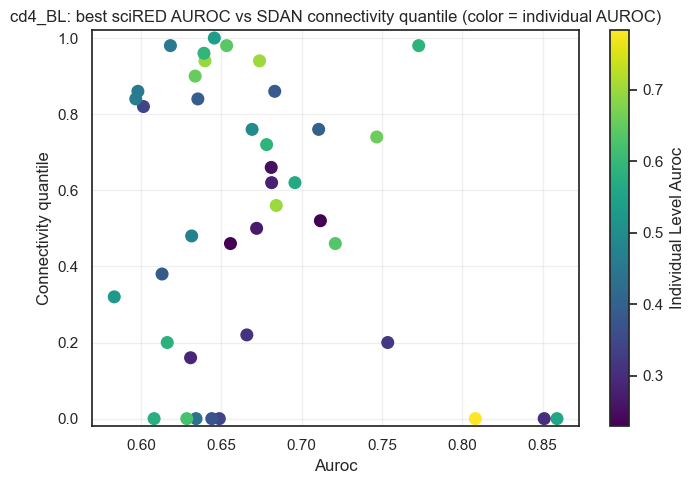

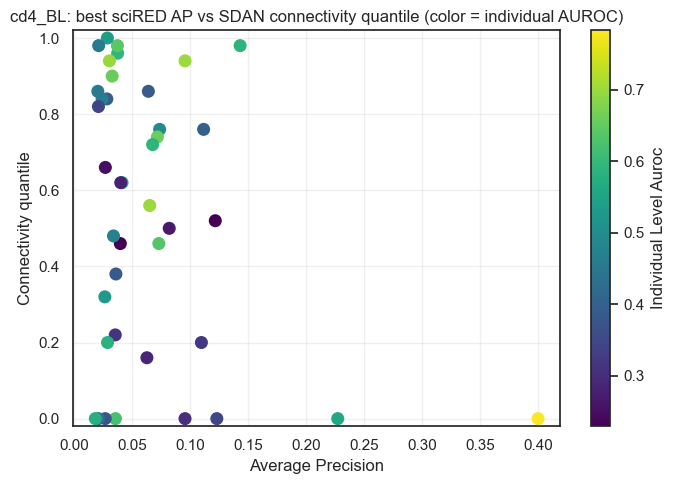

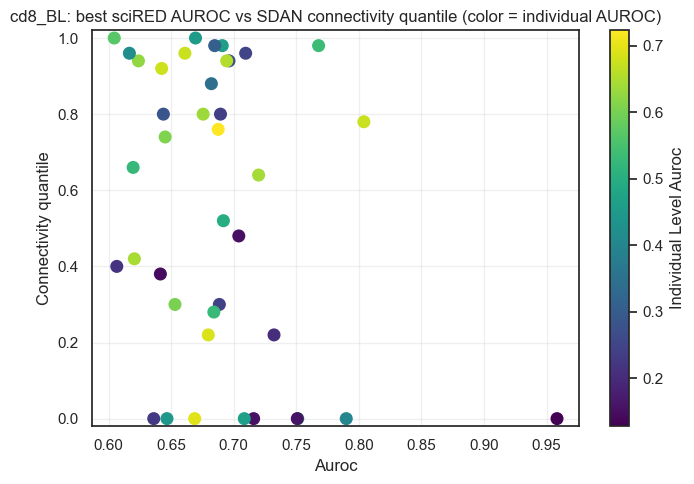

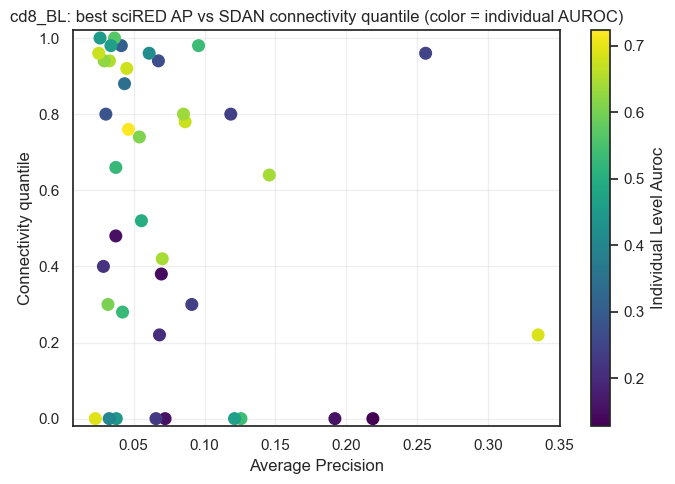

In [69]:
# SDAN vs sciRED: connectivity scatterplots for both Su_2020 cell types.

best_scired_ap = pd.read_csv(RESULTS_DIR / f"{DATASET}_best_matches_by_average_precision.csv")
best_scired_auroc = pd.read_csv(RESULTS_DIR / f"{DATASET}_best_matches_by_auroc.csv")
display(best_scired_ap.head())
display(best_scired_auroc.head())

for cell_type in CELL_TYPES:
    plot_saved_best_match_score(
        best_scired_auroc,
        cell_type,
        score_col="auroc",
        hue_col="individual_level_auroc",
        title=f"{cell_type}: best sciRED AUROC vs SDAN connectivity quantile (color = individual AUROC)",
    )
    plot_saved_best_match_score(
        best_scired_ap,
        cell_type,
        score_col="average_precision",
        hue_col="individual_level_auroc",
        title=f"{cell_type}: best sciRED AP vs SDAN connectivity quantile (color = individual AUROC)",
    )


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_18,Spectra_10,2000,2966,952,20,5,0.535797,0.206070,20,14,1.400000,0.98,0.547233,0.639881
1,cd4_BL,2.0,SDAN_3,Spectra_3,2000,2966,952,22,17,0.889902,0.183652,22,6,0.545455,0.52,0.327345,0.229167
2,cd4_BL,2.0,SDAN_11,Spectra_17,2000,2966,952,22,10,0.810191,0.155789,22,4,0.363636,0.48,0.457807,0.470238
3,cd4_BL,2.0,SDAN_12,Spectra_15,2000,2966,952,20,11,0.780698,0.147167,20,6,0.600000,0.76,0.420989,0.395833
4,cd4_BL,2.0,SDAN_24,Spectra_37,2000,2966,952,19,8,0.417638,0.131817,19,4,0.421053,0.50,0.316419,0.267857


,cell_type,sdan_weight,program,factor,n_sdan_genes,n_spectra_genes,n_genes_overlap,n_program_genes_total,n_program_genes_overlap,auroc,average_precision,n_active_genes,n_internal_edges,avg_degree,connectivity_quantile,test_group_auroc,individual_level_auroc
0,cd4_BL,2.0,SDAN_34,Spectra_39,2000,2966,952,20,3,0.890060,0.096389,20,20,2.000000,0.98,0.573280,0.586310
1,cd4_BL,2.0,SDAN_3,Spectra_3,2000,2966,952,22,17,0.889902,0.183652,22,6,0.545455,0.52,0.327345,0.229167
2,cd4_BL,2.0,SDAN_30,Spectra_1,2000,2966,952,20,3,0.864419,0.016682,20,6,0.600000,0.56,0.569940,0.699405
3,cd4_BL,2.0,SDAN_33,Spectra_3,2000,2966,952,19,6,0.843728,0.061543,19,6,0.631579,0.72,0.499512,0.589286
4,cd4_BL,2.0,SDAN_19,Spectra_14,2000,2966,952,20,9,0.832803,0.089424,20,0,0.000000,0.00,0.485626,0.437500


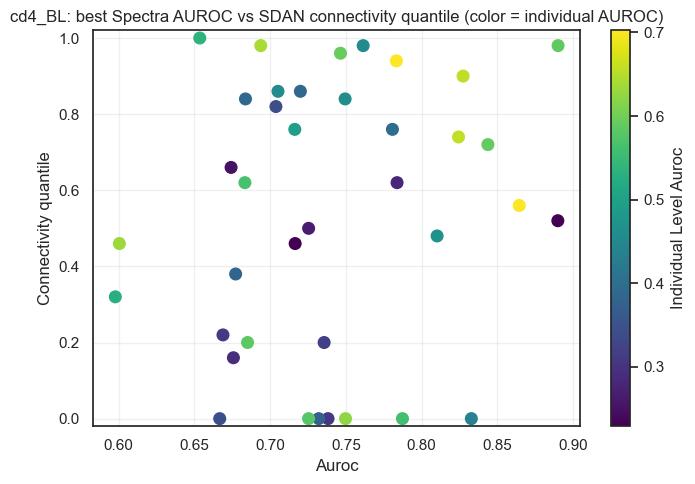

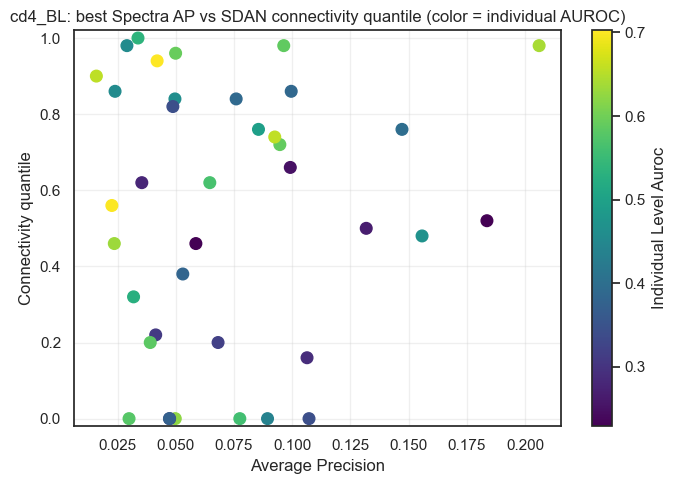

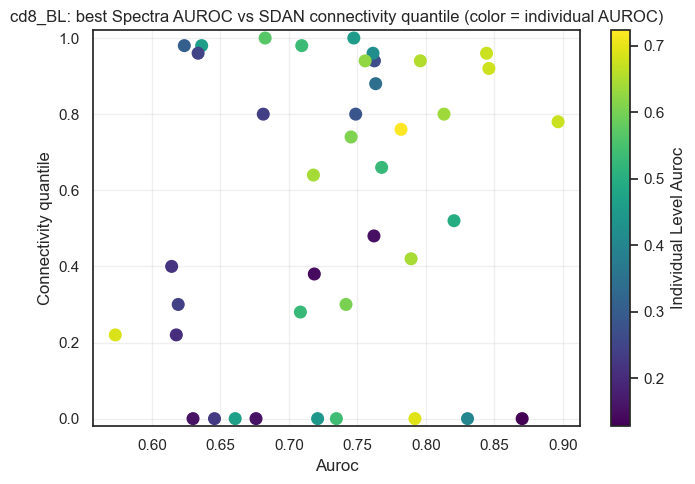

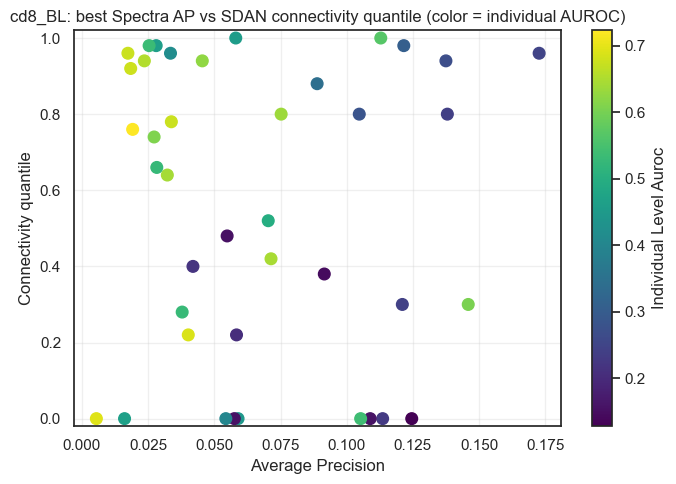

In [70]:
# SDAN vs Spectra: connectivity scatterplots for both Su_2020 cell types.

best_spectra_ap = pd.read_csv(SPECTRA_RESULTS_DIR / f"{DATASET}_best_Spectra_matches_by_average_precision.csv")
best_spectra_auroc = pd.read_csv(SPECTRA_RESULTS_DIR / f"{DATASET}_best_Spectra_matches_by_auroc.csv")
display(best_spectra_ap.head())
display(best_spectra_auroc.head())

for cell_type in CELL_TYPES:
    plot_saved_best_match_score(
        best_spectra_auroc,
        cell_type,
        score_col="auroc",
        hue_col="individual_level_auroc",
        title=f"{cell_type}: best Spectra AUROC vs SDAN connectivity quantile (color = individual AUROC)",
    )
    plot_saved_best_match_score(
        best_spectra_ap,
        cell_type,
        score_col="average_precision",
        hue_col="individual_level_auroc",
        title=f"{cell_type}: best Spectra AP vs SDAN connectivity quantile (color = individual AUROC)",
    )
